In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/cleaned_nutrition_dataset.csv')

# 1. CLEANING
# -----------------------------------
# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Remove duplicates
initial_shape = df.shape
df = df.drop_duplicates()
print(f"Removed {initial_shape[0] - df.shape[0]} duplicate rows.")

# Check for missing values
missing = df.isnull().sum()
print("\nMissing values per column:\n", missing[missing > 0])

# Handle missing values
# Strategy: drop rows with too many missing values, fill others with median (for numeric)
threshold = len(df.columns) * 0.5
df = df.dropna(thresh=threshold)

# Fill numeric columns with median
for col in df.select_dtypes(include='number').columns:
    df[col].fillna(df[col].median(), inplace=True)

# 2. PROCESSING
# -----------------------------------
# Convert object columns that are numeric
for col in df.select_dtypes(include='object').columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except ValueError:
        pass  # Leave if it can't be converted

# Create new feature (example: calories per gram)
if 'calories' in df.columns and 'weight' in df.columns:
    df['calories_per_gram'] = df['calories'] / df['weight']

# 3. ANALYSIS
# -----------------------------------
# Summary statistics
print("\nSummary statistics:\n", df.describe())






Removed 0 duplicate rows.

Missing values per column:
 Series([], dtype: int64)

Summary statistics:
          vitamin_c  vitamin_b11        sodium      calcium  carbohydrates  \
count  3454.000000  3454.000000   3454.000000  3454.000000    3454.000000   
mean      9.501021    11.447140    141.437806    53.953960      18.724570   
std      70.387542    33.849817    973.168394   103.339195      26.232674   
min       0.000000     0.000000      0.000000     0.000000       0.000000   
25%       0.000000     0.029000      0.057000     4.647500       1.700000   
50%       0.300000     0.075000      0.200000    21.940000       9.110000   
75%       5.382500     4.327500     21.372500    60.600000      26.400000   
max    3872.000000   550.520000  14174.590000  1283.500000     390.200000   

              iron  caloric_value       sugars  dietary_fiber          fat  \
count  3454.000000    3454.000000  3454.000000    3454.000000  3454.000000   
mean      1.627954     227.591546     5.693513  

<ipython-input-5-a53bd872b7b7>:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


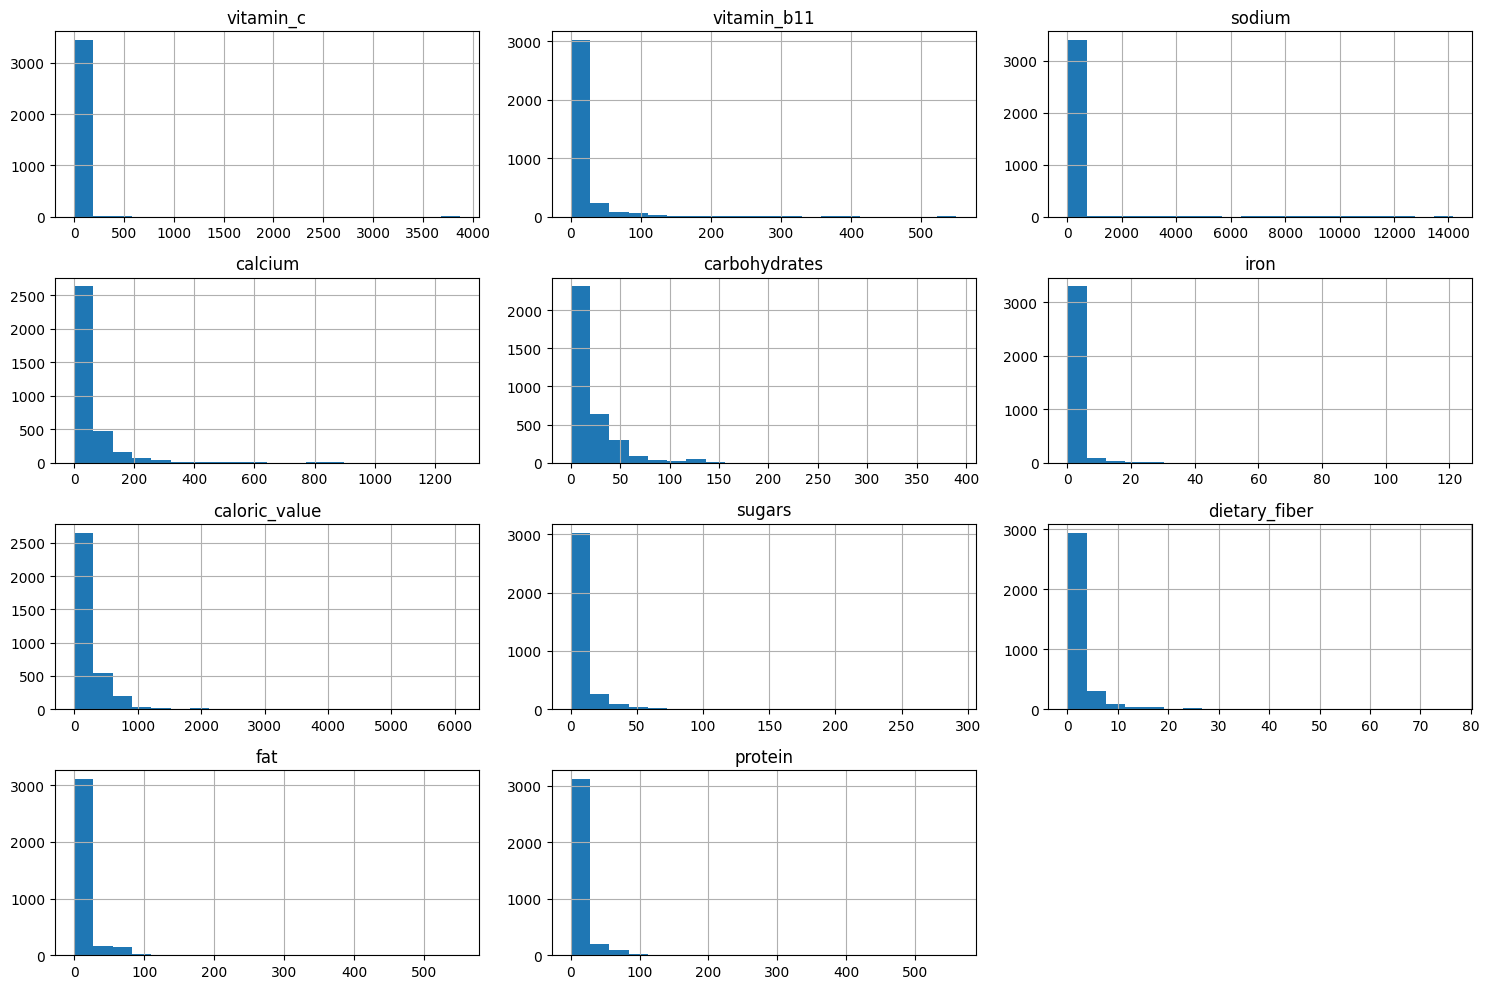

In [ ]:
# Histograms of numeric features
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols].hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

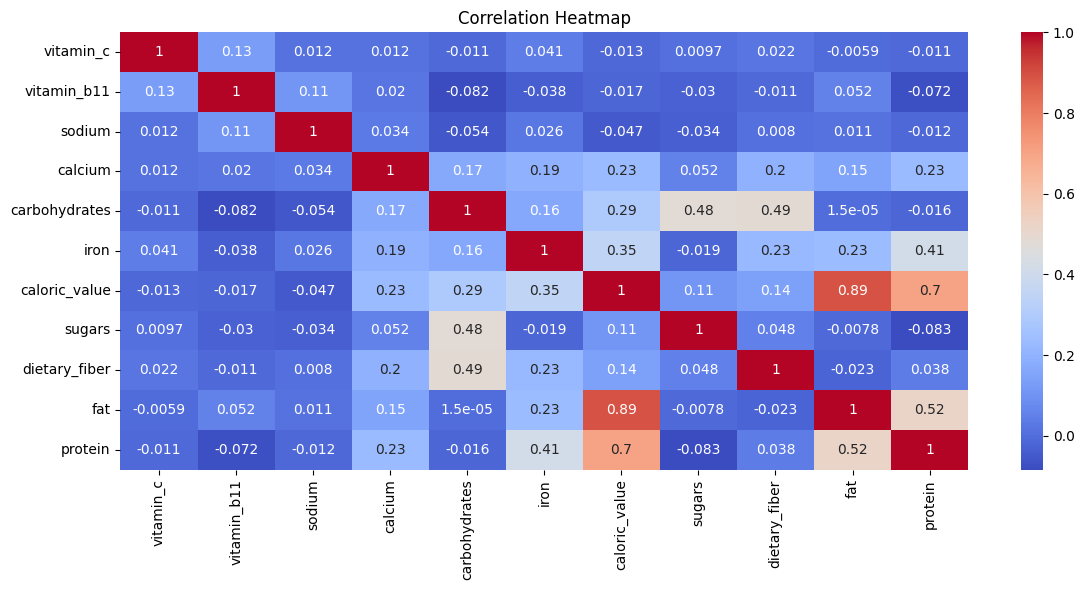

In [ ]:
# Correlation heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


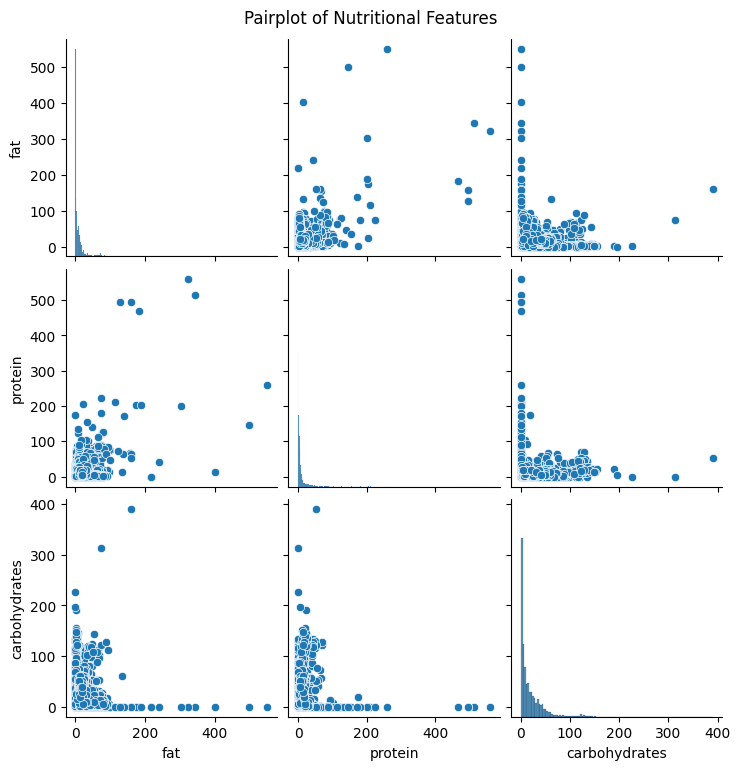

In [ ]:
# Choose a few important features for pairplot
important_features = ['calories', 'fat', 'protein', 'carbohydrates']
selected = [col for col in important_features if col in df.columns]

if len(selected) >= 2:
    sns.pairplot(df[selected])
    plt.suptitle("Pairplot of Nutritional Features", y=1.02)
    plt.show()



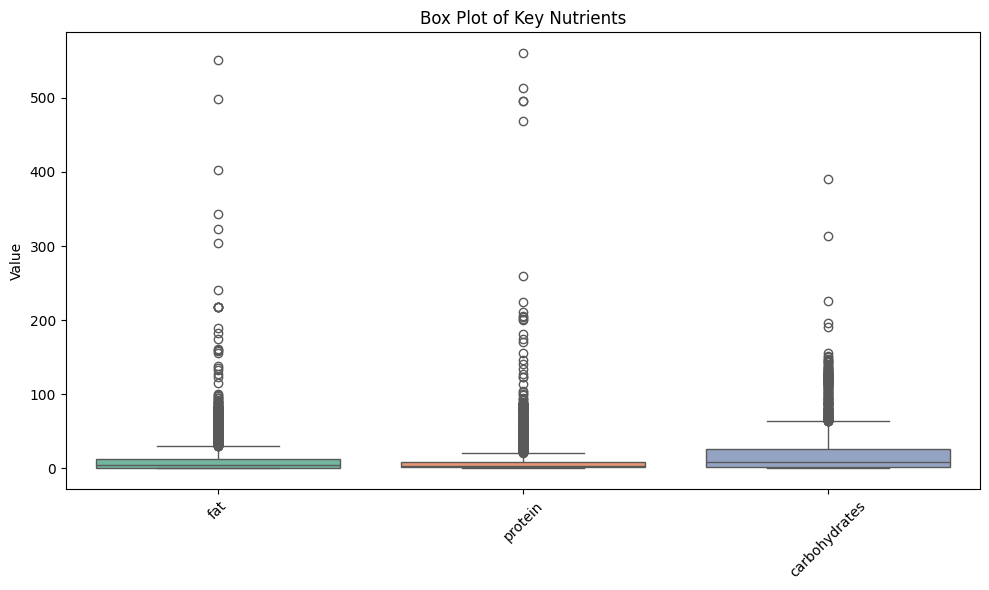

In [ ]:
# Box plot of key nutrients
key_nutrients = ['calories', 'fat', 'protein', 'carbohydrates']
available = [col for col in key_nutrients if col in df.columns]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[available], palette='Set2')
plt.title("Box Plot of Key Nutrients")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
